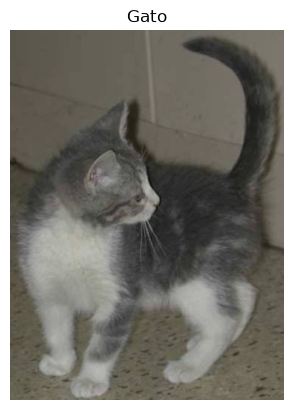

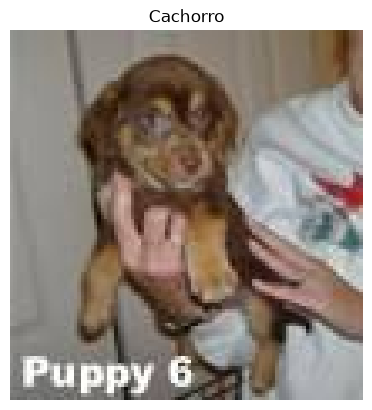

In [1]:
# Importa funções para manipulação de arquivos e diretórios
import os

# Importa funções para sorteio aleatório
import random

# Biblioteca para exibição de gráficos e imagens
import matplotlib.pyplot as plt

# Biblioteca para abertura e manipulação de imagens
from PIL import Image

import numpy as np


# Função que exibe uma imagem aleatória de uma pasta
def mostrar_imagem_aleatoria(pasta, label):

    # Obtém a lista de arquivos da pasta informada
    arquivos = os.listdir(pasta)

    # Escolhe um arquivo aleatoriamente
    escolhido = random.choice(arquivos)

    # Monta o caminho completo da imagem e a abre
    img = Image.open(os.path.join(pasta, escolhido))

    # Exibe a imagem
    plt.imshow(img)

    # Define o título da imagem
    plt.title(label)

    # Remove os eixos da figura
    plt.axis("off")

    # Mostra a imagem na tela
    plt.show()


# Mostra uma imagem aleatória da pasta de gatos
mostrar_imagem_aleatoria("data/train/cat", "Gato")

# Mostra uma imagem aleatória da pasta de cachorros
mostrar_imagem_aleatoria("data/train/dog", "Cachorro")

In [ ]:
def preprocessar_imagem(caminho):  
    # Função que recebe o caminho de uma imagem e a prepara para uso em IA

    img = Image.open(caminho)
    # Abre a imagem do arquivo usando PIL (Pillow)

    img = img.resize((64, 64))
    # Redimensiona a imagem para 64x64 pixels
    # Isso padroniza todas as imagens para o mesmo tamanho

    img = img.convert("L")
    # Converte a imagem para escala de cinza (L = luminância)
    # Remove cores e deixa apenas intensidade (0 a 255)

    img = np.array(img).astype(np.float32) / 255.0
    # Converte a imagem em um array NumPy
    # Transforma os valores em float (números reais)
    # Normaliza os pixels para o intervalo 0 a 1

    img = img.flatten()
    # "Achata" a imagem (matriz vira vetor)
    # Ex: 64x64 vira um vetor de 4096 valores

    return img
    # Retorna a imagem já processada para a IAdef preprocessar_imagem(caminho):   #conversão pra IA burra que nao entende nada
    

In [ ]:
def carregar_dados():  
    # Função responsável por carregar todas as imagens
    # e transformar em dados para treinar uma IA (gato vs cachorro)

    X = []
    # Lista onde serão armazenadas as imagens já processadas (features)

    y = []
    # Lista onde serão armazenados os rótulos (labels)
    # 0 = gato, 1 = cachorro

    # Percorre todas as imagens da pasta de gatos
    for img_name in os.listdir("data/train/cat"):
        # Monta o caminho completo da imagem
        path = "data/train/cat/" + img_name

        # Processa a imagem (resize, grayscale, normalização, flatten)
        X.append(preprocessar_imagem(path))

        # Adiciona o rótulo 0 (gato)
        y.append(0)

    # Percorre todas as imagens da pasta de cachorros
    for img_name in os.listdir("data/train/dog"):
        # Monta o caminho completo da imagem
        path = "data/train/dog/" + img_name

        # Processa a imagem e adiciona à lista X
        X.append(preprocessar_imagem(path))

        # Adiciona o rótulo 1 (cachorro)
        y.append(1)

    # Converte as listas para arrays NumPy (formato ideal para IA)
    return np.array(X), np.array(y)


# Executa a função e separa os dados em:
# X = imagens processadas
# y = classes (0 ou 1)
X, y = carregar_dados()

In [ ]:
# Converte os dados de entrada (imagens) para float32
# Isso deixa os valores mais leves e adequados para IA
X = X.astype(np.float32)

# Converte os rótulos (0 = gato, 1 = cachorro) para float32
y = y.astype(np.float32)


# Normalização dos dados (padronização)
# Fórmula: (valor - média) / desvio padrão
# Isso ajuda a IA a aprender melhor e mais rápido
X = (X - X.mean()) / (X.std() + 1e-8)
# O +1e-8 evita divisão por zero caso o desvio padrão seja muito pequeno


# Gera uma ordem aleatória dos índices dos dados
# Isso evita que o modelo aprenda padrões de ordem (ex: todos gatos primeiro)
indices = np.random.permutation(len(X))

# Reorganiza X (imagens) de forma aleatória
X = X[indices]

# Reorganiza y (labels) na mesma ordem de X
y = y[indices]


# Mostra o formato dos dados
# X shape = quantidade de imagens e tamanho de cada vetor
# y shape = quantidade de labels
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (300, 4096)
y shape: (300,)


In [ ]:
def sigmoid(x):
    # Função de ativação Sigmoid
    # Converte qualquer valor em um número entre 0 e 1
    # Muito usada para problemas de classificação binária (0 ou 1)
    return 1 / (1 + np.exp(-x))


def relu(x):
    # Função de ativação ReLU (Rectified Linear Unit)
    # Se o valor for negativo, retorna 0
    # Se for positivo, retorna o próprio valor
    # Muito usada em redes neurais profundas por ser simples e eficiente
    return np.maximum(0, x)

In [ ]:
# Número de neurônios da camada de entrada
# 4096 porque a imagem 64x64 foi "achatada" (64*64 = 4096)
entrada = 4096

# Número de neurônios da camada oculta (hidden layer)
# Aqui o modelo aprende padrões intermediários
oculta = 128

# Número de neurônios da camada de saída
# 1 porque é classificação binária (gato ou cachorro)
saida = 1


# Define uma semente para reprodutibilidade
# Isso garante que os mesmos números aleatórios sejam gerados sempre
np.random.seed(42)


# Inicialização dos pesos da primeira camada (entrada → oculta)
# randn gera valores aleatórios com distribuição normal
# sqrt(2 / entrada) é inicialização He (boa para ReLU)
W1 = np.random.randn(entrada, oculta) * np.sqrt(2 / entrada)

# Bias da primeira camada (inicializado com zeros)
b1 = np.zeros((1, oculta))


# Inicialização dos pesos da segunda camada (oculta → saída)
# Também usando inicialização He adaptada
W2 = np.random.randn(oculta, saida) * np.sqrt(2 / oculta)

# Bias da segunda camada (inicializado com zeros)
b2 = np.zeros((1, saida))

In [ ]:
# Taxa de aprendizado (learning rate)
# Controla o tamanho do passo que a IA dá ao aprender
# Valores pequenos = aprendizado mais lento, porém mais estável
# Valores grandes = aprendizado mais rápido, mas pode ficar instável
lr = 0.01


# Número de épocas (epochs)
# Quantas vezes o modelo vai ver TODO o conjunto de dados durante o treino
# Mais épocas = mais aprendizado (até certo ponto)
epochs = 50

In [ ]:
def treinar(X, y):
    # Função responsável por treinar a rede neural (backpropagation)
    
    global W1, b1, W2, b2
    # Permite modificar os pesos e biases globais da rede

    m = X.shape[0]
    # Número de amostras (imagens) no dataset

    for epoch in range(epochs):
        # Loop de treinamento: repete o processo várias vezes (épocas)

        # ---------------- FORWARD PASS ----------------

        Z1 = X @ W1 + b1
        # Entrada passando pela 1ª camada (multiplicação + bias)

        A1 = relu(Z1)
        # Aplicação da função ReLU (ativa a rede)

        Z2 = A1 @ W2 + b2
        # Saída da camada oculta indo para camada de saída

        A2 = sigmoid(Z2)
        # Função sigmoid transforma saída em probabilidade (0 a 1)

        A2 = np.clip(A2, 1e-8, 1 - 1e-8)
        # Evita log(0) na função de perda (estabilidade numérica)


        # ---------------- LOSS (ERRO) ----------------

        loss = -np.mean(
            y.reshape(-1,1) * np.log(A2) +
            (1 - y.reshape(-1,1)) * np.log(1 - A2)
        )
        # Função de perda (Binary Cross Entropy)
        # Mede o quão errada está a rede


        # ---------------- ACURÁCIA ----------------

        preds = (A2 > 0.5).astype(int)
        # Converte probabilidades em classe (0 ou 1)

        acc = np.mean(preds == y.reshape(-1,1))
        # Calcula a taxa de acerto do modelo

        print(f"Epoch {epoch+1:02d} - Loss: {loss:.4f} - Acc: {acc:.4f}")
        # Mostra evolução do treino


        # ---------------- BACKPROPAGATION ----------------

        dZ2 = A2 - y.reshape(-1,1)
        # Erro da camada de saída

        dW2 = (A1.T @ dZ2) / m
        # Gradiente dos pesos da camada 2

        db2 = np.sum(dZ2, axis=0, keepdims=True) / m
        # Gradiente do bias da camada 2

        dA1 = dZ2 @ W2.T
        # Propaga erro para camada oculta

        dZ1 = dA1 * (Z1 > 0)
        # Derivada da ReLU

        dW1 = (X.T @ dZ1) / m
        # Gradiente dos pesos da camada 1

        db1 = np.sum(dZ1, axis=0, keepdims=True) / m
        # Gradiente do bias da camada 1


        # ---------------- ATUALIZAÇÃO DOS PESOS ----------------

        W1 -= lr * dW1
        # Atualiza pesos da camada 1

        b1 -= lr * db1
        # Atualiza bias da camada 1

        W2 -= lr * dW2
        # Atualiza pesos da camada 2

        b2 -= lr * db2
        # Atualiza bias da camada 2

In [10]:
treinar(X, y)

Epoch 01 - Loss: 0.3409 - Acc: 0.9567
Epoch 02 - Loss: 0.3373 - Acc: 0.9633
Epoch 03 - Loss: 0.3337 - Acc: 0.9667
Epoch 04 - Loss: 0.3302 - Acc: 0.9667
Epoch 05 - Loss: 0.3268 - Acc: 0.9667
Epoch 06 - Loss: 0.3234 - Acc: 0.9667
Epoch 07 - Loss: 0.3201 - Acc: 0.9667
Epoch 08 - Loss: 0.3168 - Acc: 0.9700
Epoch 09 - Loss: 0.3136 - Acc: 0.9700
Epoch 10 - Loss: 0.3104 - Acc: 0.9700
Epoch 11 - Loss: 0.3073 - Acc: 0.9733
Epoch 12 - Loss: 0.3042 - Acc: 0.9733
Epoch 13 - Loss: 0.3012 - Acc: 0.9733
Epoch 14 - Loss: 0.2983 - Acc: 0.9733
Epoch 15 - Loss: 0.2954 - Acc: 0.9733
Epoch 16 - Loss: 0.2925 - Acc: 0.9733
Epoch 17 - Loss: 0.2897 - Acc: 0.9733
Epoch 18 - Loss: 0.2869 - Acc: 0.9767
Epoch 19 - Loss: 0.2841 - Acc: 0.9767
Epoch 20 - Loss: 0.2815 - Acc: 0.9767
Epoch 21 - Loss: 0.2788 - Acc: 0.9767
Epoch 22 - Loss: 0.2762 - Acc: 0.9767
Epoch 23 - Loss: 0.2736 - Acc: 0.9767
Epoch 24 - Loss: 0.2711 - Acc: 0.9767
Epoch 25 - Loss: 0.2686 - Acc: 0.9800
Epoch 26 - Loss: 0.2661 - Acc: 0.9800
Epoch 27 - L